In [7]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix

c:\Users\omar mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\omar mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
c:\Users\omar mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at te

In [ ]:
DATA_DIR = 'brain_tumor_dataset' 
CATEGORIES = ['no', 'yes'] 
IMG_SIZE = 128 

data = []



for category in CATEGORIES:
    path = os.path.join(DATA_DIR, category)
    class_num = CATEGORIES.index(category) 
    
   
    for img_name in os.listdir(path):
        try:
           
            img_path = os.path.join(path, img_name)
            img_array = cv2.imread(img_path)
            
           
            new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
            
           
            data.append([new_array, class_num])
        except Exception as e:
            pass 

print(f"✅ Loaded {len(data)} images successfully.")

⏳ Loading Images... Please wait.
✅ Loaded 253 images successfully.



--- Data Summary ---
Total Samples: 253
Image Shape: (128, 128, 3)
label
1    155
0     98
Name: count, dtype: int64

👁️ Inspecting Samples:


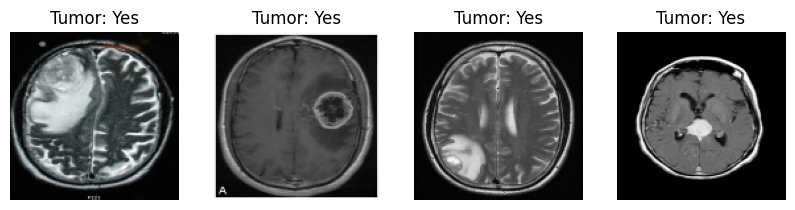

In [ ]:
df_data = pd.DataFrame(data, columns=['image_matrix', 'label'])

print("\n--- Data Summary ---")
print(f"Total Samples: {len(df_data)}")
print(f"Image Shape: ({IMG_SIZE}, {IMG_SIZE}, 3)")
print(df_data['label'].value_counts()) 

# 3. Inspect Sample Images 

plt.figure(figsize=(10,5))
for i in range(4):
    plt.subplot(1, 4, i+1)
    # عرض صورة عشوائية
    sample = data[np.random.randint(0, len(data))]
    plt.imshow(cv2.cvtColor(sample[0], cv2.COLOR_BGR2RGB)) 
    plt.title("Tumor: Yes" if sample[1] == 1 else "Tumor: No")
    plt.axis('off')
plt.show()

In [ ]:
print("\n" + "="*40)
print("🔍 STEP 2: DUPLICATE HANDLING")
print("="*40)


df_data['image_flat'] = df_data['image_matrix'].apply(lambda x: x.flatten().tobytes())


duplicates = df_data.duplicated(subset=['image_flat'])
num_duplicates = duplicates.sum()

print(f"⚠️ Found {num_duplicates} duplicate images.")
print(f"Percentage: {(num_duplicates/len(df_data))*100:.2f}%")


if num_duplicates > 0:
    df_data = df_data.drop_duplicates(subset=['image_flat'])
    print(f" Duplicates removed. New count: {len(df_data)}")
else:
    print(" No duplicates found.")

# نرجع الداتا لشكلها الأصلي عشان نكمل شغل
final_data = df_data[['image_matrix', 'label']].values.tolist()



🔍 STEP 2: DUPLICATE HANDLING
⚠️ Found 25 duplicate images.
Percentage: 9.88%
✅ Duplicates removed. New count: 228

🚀 Ready for next steps with 228 unique images.


📊 Data Shape: X=(228, 128, 128, 3), y=(228,)

🔍 STEP 3: MISSING VALUES CHECK
Total NaN values in image data: 0
✅ No missing pixel values found.

📉 STEP 4: OUTLIER DETECTION
Found 0 outliers (Too dark/bright images).
✅ No extreme outliers found.

📊 STEP 5: VISUALIZATIONS


C:\Users\omar mohamed\AppData\Local\Temp\ipykernel_9700\1339740220.py:74: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette=['#4CAF50', '#FF5252'])


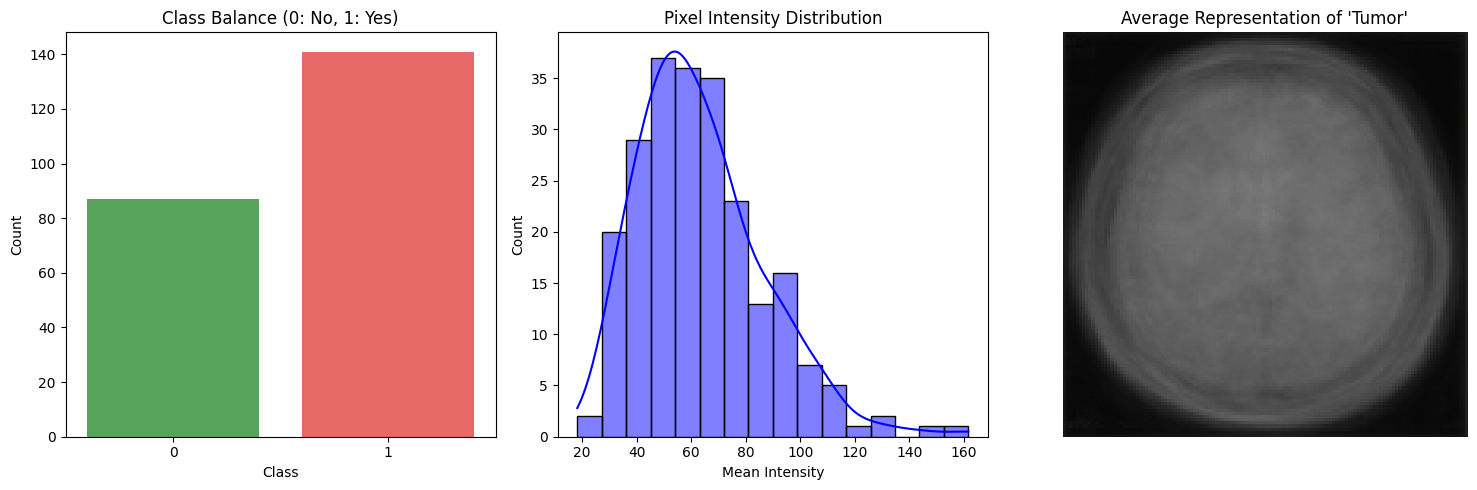


💡 Insights for Discussion:
- The Histogram shows us if the MRI scans are well-contrasted.
- The Bar Chart tells us if we need balancing techniques (Step 6).


In [ ]:
# ==========================================
# PREPARATION: Separate X (Images) and y (Labels)
# ==========================================

X = []
y = []

for features, label in final_data:
    X.append(features)
    y.append(label)


X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 3)
y = np.array(y)

print(f"Data Shape: X={X.shape}, y={y.shape}")

# ==========================================
# STEP 3: HANDLE MISSING VALUES
# ==========================================
print("\n" + "="*40)
print("🔍 STEP 3: MISSING VALUES CHECK")
print("="*40)


total_nan = np.isnan(X).sum()
print(f"Total NaN values in image data: {total_nan}")

if total_nan > 0:
    print(" Handling NaNs by replacing with mean...")

    X = np.nan_to_num(X, nan=np.nanmean(X))
else:
    print("No missing pixel values found.")

# ==========================================
# STEP 4: CHECK OUTLIERS AND HANDLE THEM
# ==========================================
print("\n" + "="*40)
print("📉 STEP 4: OUTLIER DETECTION")
print("="*40)

mean_intensities = X.mean(axis=(1, 2, 3)) 

outlier_indices = np.where((mean_intensities < 10) | (mean_intensities > 245))[0]

print(f"Found {len(outlier_indices)} outliers (Too dark/bright images).")

if len(outlier_indices) > 0:

    X = np.delete(X, outlier_indices, axis=0)
    y = np.delete(y, outlier_indices, axis=0)
    print(f"✅ Outliers removed. New Data Shape: {X.shape}")
else:
    print("✅ No extreme outliers found.")

# ==========================================
# STEP 5: VISUALIZATIONS (DISTRIBUTION & BALANCE)
# ==========================================
print("\n" + "="*40)
print("STEP 5: VISUALIZATIONS")
print("="*40)

plt.figure(figsize=(15, 5))


plt.subplot(1, 3, 1)
sns.countplot(x=y, palette=['#4CAF50', '#FF5252'])
plt.title("Class Balance (0: No, 1: Yes)")
plt.xlabel("Class")
plt.ylabel("Count")


plt.subplot(1, 3, 2)
sns.histplot(X.mean(axis=(1, 2, 3)), kde=True, color='blue')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Mean Intensity")

plt.subplot(1, 3, 3)
tumor_mean_img = X[y == 1].mean(axis=0).astype('uint8')
plt.imshow(cv2.cvtColor(tumor_mean_img, cv2.COLOR_BGR2RGB))
plt.title("Average Representation of 'Tumor'")
plt.axis('off')

plt.tight_layout()
plt.show()

print("\n Insights for Discussion:")
print("- The Histogram shows us if the MRI scans are well-contrasted.")
print("- The Bar Chart tells us if we need balancing techniques (Step 6).")

In [ ]:
# ==========================================
# STEP 6: CHECK IMBALANCE AND HANDLE IT
# ==========================================
print("\n" + "="*40)
print("STEP 6: HANDLING IMBALANCE (UPSAMPLING)")
print("="*40)


X_reshaped = X.reshape(X.shape[0], -1) 
df_combined = pd.DataFrame(X_reshaped)
df_combined['label'] = y


df_no = df_combined[df_combined.label == 0] 
df_yes = df_combined[df_combined.label == 1] 


df_no_upsampled = resample(df_no, 
                           replace=True,     
                           n_samples=len(df_yes), 
                           random_state=42) 


df_balanced = pd.concat([df_yes, df_no_upsampled])

print("Old Counts:", pd.Series(y).value_counts().to_dict())
print("New Counts:", df_balanced.label.value_counts().to_dict()) 


y_final = df_balanced.label.values
X_final = df_balanced.drop('label', axis=1).values
X_final = X_final.reshape(-1, IMG_SIZE, IMG_SIZE, 3)


X_final = X_final / 255.0


⚖️ STEP 6: HANDLING IMBALANCE (UPSAMPLING)
Old Counts: {1: 141, 0: 87}
New Counts: {1: 141, 0: 141}


In [ ]:
# ==========================================
# STEP 7: MODELING & OVERFITTING HANDLING
# ==========================================
print("\n" + "="*40)
print("STEP 7: BUILDING CNN MODEL")
print("="*40)


X_train, X_test, y_train, y_test = train_test_split(X_final, y_final, test_size=0.2, random_state=42)

print(f"Train Shape: {X_train.shape} | Test Shape: {X_test.shape}")


model = Sequential()


model.add(Conv2D(32, (3,3), activation='relu', input_shape=(IMG_SIZE, IMG_SIZE, 3)))
model.add(MaxPooling2D(2,2))


model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))


model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))


model.add(Flatten())


model.add(Dense(128, activation='relu'))


model.add(Dropout(0.5)) 


model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)


🧠 STEP 7: BUILDING CNN MODEL
Train Shape: (225, 128, 128, 3) | Test Shape: (57, 128, 128, 3)


c:\Users\omar mohamed\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
print("Training Started...")
history = model.fit(X_train, y_train, 
                    epochs=20, 
                    batch_size=32, 
                    validation_data=(X_test, y_test),
                    callbacks=[early_stop])


model.save('brain_tumor_model.h5')
print("Model Saved as 'brain_tumor_model.h5'")


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

print(f"\n Final Test Accuracy: {test_acc * 100:.2f}%")

🚀 Training Started...
Epoch 1/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9956 - loss: 0.0418 - val_accuracy: 0.9825 - val_loss: 0.2200
Epoch 2/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 89ms/step - accuracy: 0.9822 - loss: 0.0514 - val_accuracy: 0.9474 - val_loss: 0.2663
Epoch 3/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9956 - loss: 0.0277 - val_accuracy: 0.9825 - val_loss: 0.2948
Epoch 4/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.9911 - loss: 0.0258 - val_accuracy: 0.9474 - val_loss: 0.2848
Epoch 5/20
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - accuracy: 1.0000 - loss: 0.0122 - val_accuracy: 0.9474 - val_loss: 0.3173


💾 Model Saved as 'brain_tumor_model.h5'

🏆 Final Test Accuracy: 98.25%



📈 STEP 8: EVALUATION


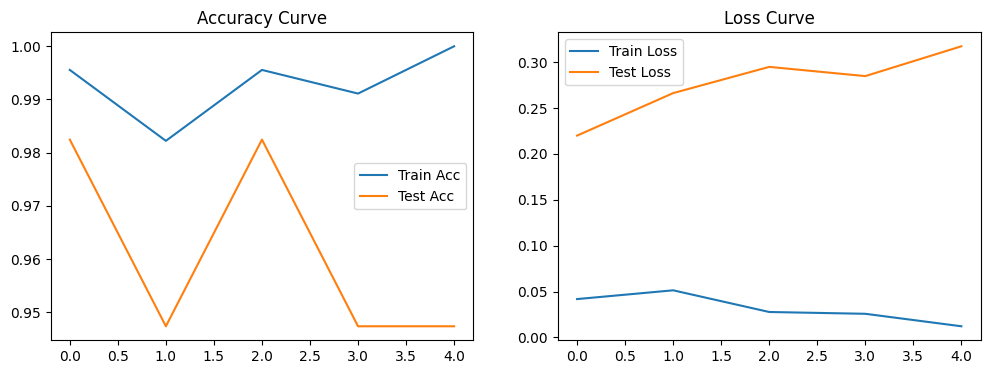

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step

Confusion Matrix:


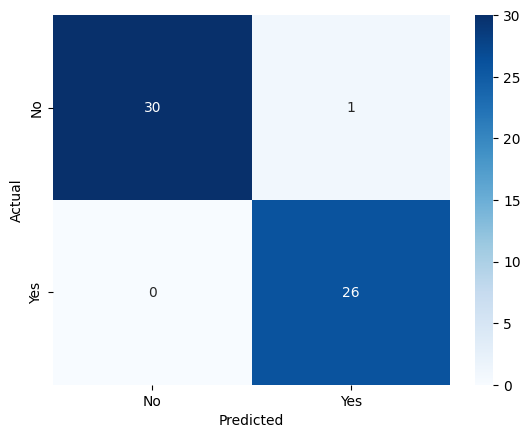


Classification Report:
              precision    recall  f1-score   support

No (Healthy)       1.00      0.97      0.98        31
 Yes (Tumor)       0.96      1.00      0.98        26

    accuracy                           0.98        57
   macro avg       0.98      0.98      0.98        57
weighted avg       0.98      0.98      0.98        57



In [ ]:
# ==========================================
# STEP 8: EVALUATION
# ==========================================
print("\n" + "="*40)
print("STEP 8: EVALUATION")
print("="*40)


plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Test Acc')
plt.title('Accuracy Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Test Loss')
plt.title('Loss Curve')
plt.legend()
plt.show()


y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int) 


print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No (Healthy)', 'Yes (Tumor)']))